In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [13]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 30

train_dir = 'RiceLeafsDisease/train'
val_dir = 'RiceLeafsDisease/validation'
test_dir = 'RiceLeafsDisease/test'

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.4,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2100 images belonging to 6 classes.
Found 264 images belonging to 6 classes.
Found 264 images belonging to 6 classes.


In [15]:
# Load pre-trained DenseNet121
base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
base_model.trainable = False  # Freeze base model initially

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 109s 4us/step


In [16]:
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
checkpoint = ModelCheckpoint('best_densenet_model.keras',
                              monitor='val_accuracy',
                              save_best_only=True,
                              verbose=1)

earlystop = EarlyStopping(monitor='val_accuracy',
                           patience=5,
                           restore_best_weights=True,
                           verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                               factor=0.5,
                               patience=2,
                               min_lr=1e-6,
                               verbose=1)

In [18]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3411 - loss: 1.7387
Epoch 1: val_accuracy improved from -inf to 0.76894, saving model to best_densenet_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.3431 - loss: 1.7335 - val_accuracy: 0.7689 - val_loss: 0.7525 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6396 - loss: 0.9574
Epoch 2: val_accuracy improved from 0.76894 to 0.79167, saving model to best_densenet_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.6397 - loss: 0.9570 - val_accuracy: 0.7917 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6611 - loss: 0.9281
Epoch 3: val_accuracy improved from 0.79167 to 0.82955, saving model to best_densenet_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.6610 - loss: 0.9278 - val_accuracy: 0.8295 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s

In [19]:
# Unfreeze full base model for fine-tuning
base_model.trainable = True

# Lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5540 - loss: 2.0936 
Epoch 1: val_accuracy did not improve from 0.90909
66/66 ━━━━━━━━━━━━━━━━━━━━ 906s 13s/step - accuracy: 0.5556 - loss: 2.0823 - val_accuracy: 0.7765 - val_loss: 0.5068 - learning_rate: 1.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7845 - loss: 0.6256 
Epoch 2: val_accuracy improved from 0.90909 to 0.91667, saving model to best_densenet_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 844s 13s/step - accuracy: 0.7850 - loss: 0.6244 - val_accuracy: 0.9167 - val_loss: 0.1970 - learning_rate: 1.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8714 - loss: 0.3554 
Epoch 3: val_accuracy improved from 0.91667 to 0.93182, saving model to best_densenet_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 865s 13s/step - accuracy: 0.8715 - loss: 0.3554 - val_accuracy: 0.9318 - val_loss: 0.2044 - learning_rate: 1.0000e-04
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0

In [20]:
model.load_weights('best_densenet_model.keras')

test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9701 - loss: 0.1074

✅ Final Test Accuracy: 97.35%


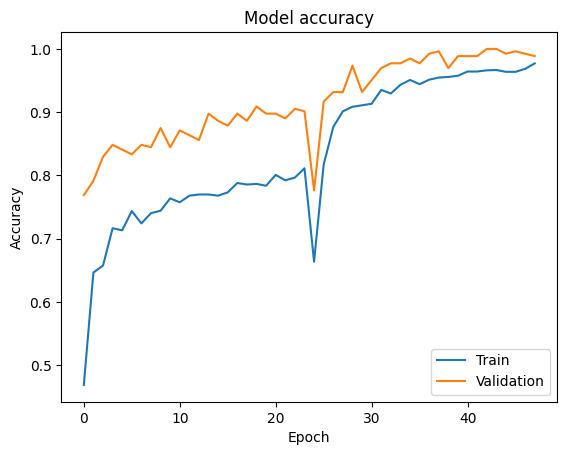

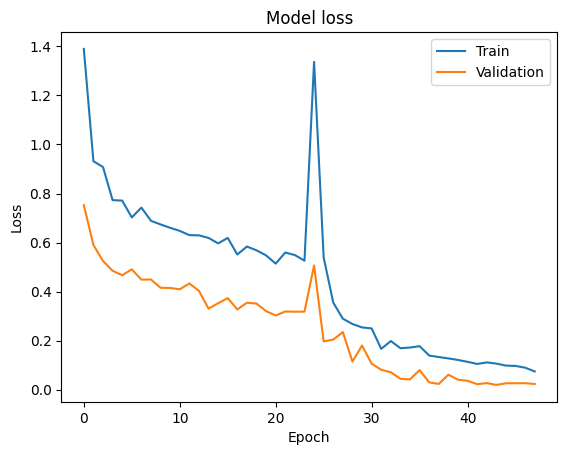

In [21]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

# Loss plot
plt.plot(history.history['loss'] + history_fine.history['loss'])
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step


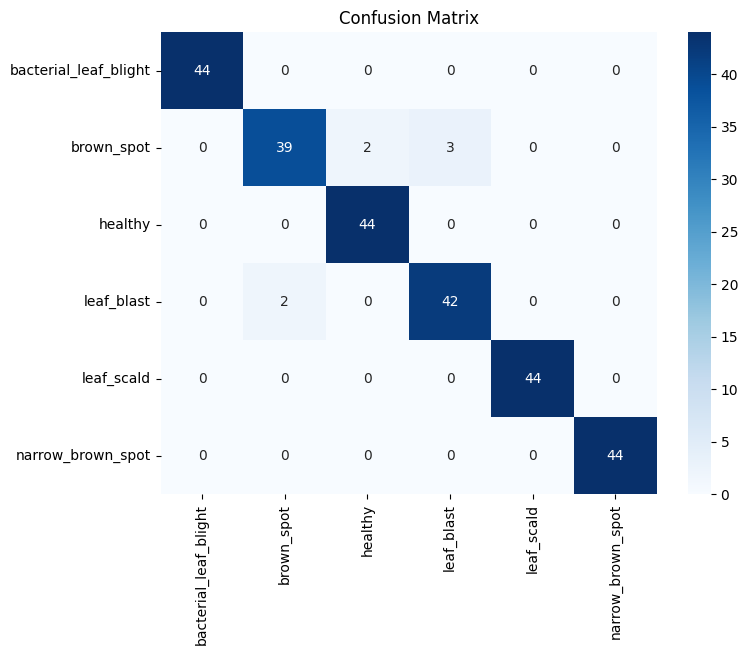

                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      1.00      1.00        44
           brown_spot       0.95      0.89      0.92        44
              healthy       0.96      1.00      0.98        44
           leaf_blast       0.93      0.95      0.94        44
           leaf_scald       1.00      1.00      1.00        44
    narrow_brown_spot       1.00      1.00      1.00        44

             accuracy                           0.97       264
            macro avg       0.97      0.97      0.97       264
         weighted avg       0.97      0.97      0.97       264



In [22]:
# Generate Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict test set
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(true_classes, y_pred, target_names=class_labels))

In [27]:
#Save final model for deployment
model.save("rice_leaf_densenet121_final_model.keras")

In [26]:
#Predict Single Images (for deployment testing)
from tensorflow.keras.preprocessing import image
import numpy as np

import os

img_path = os.path.join('RiceLeafsDisease', 'test', 'leaf_blast', 'leaf_blast_val (45).jpg')


img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_names = list(train_generator.class_indices.keys())

print("Predicted Class:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Predicted Class: leaf_blast
